<a href="https://colab.research.google.com/github/nickplas/Intro_to_ML_25-26/blob/main/notebooks/Lab-3.Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Apprendimento Supervisionato: Regressione Lineare e Logistica

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
np.random.seed(404)

## Generazione dei Dati (vedi Lab 1)

Modello lineare $y=wx+\varepsilon$, con $\varepsilon \sim \mathcal{N}(0,\sigma)$

In [2]:
def datagen(d, points, m, M, w, sigma):
    """
    Parametri
    ----------
    - d : int
        Dimensione di ciascun campione di dati

    - points : int
        Numero di punti da generare

    - m : float
        Limite inferiore del dominio dei punti dati

    - M : float
        Limite superiore del dominio dei punti dati

    - w : array di float di dimensione d
        Vettore dei pesi del modello lineare

    - sigma : float
        Deviazione standard del rumore eps
    """
    X = np.zeros((points, d))
    for i in range(points):
        X[i,:] = np.random.uniform(m, M, d)
    eps = np.random.normal(0, sigma, points)
    y = np.dot(X, w) + eps
    return X, y

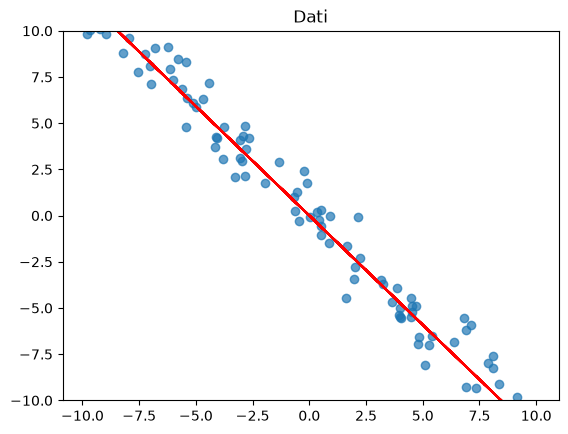

In [3]:
# esempio d'uso
d = 1
w = np.random.normal(0, 1, d)
sigma = 1
points = 100
m = -10
M = 10

X_reg, y_reg = datagen(d, points, m, M, w, sigma)

# grafico del dataset generato
plt.scatter(X_reg, y_reg, alpha = 0.7)
plt.plot(X_reg, np.dot(X_reg, w), '--', c='r')
plt.title('Dati')
plt.ylim([m, M])

plt.show()

## Regressione Lineare

Dato un dataset $\mathcal{D}=\{(x_i, y_i)\}_{i=1}^n ⊆ \mathbb{R}^d \times \mathbb{R}$ vogliamo calcolare la retta che meglio si adatta ai dati, cioè i parametri $w$ della retta $y=X\cdot w$.

### Soluzione Analitica

* **Regressione Lineare Ordinaria (cioè senza regolarizzazione):**

$$
y=Xw,\;\;\;\; w=X^{-1}y,\;\;\;\;X^{-1}=(X^{T}X)^{-1}X^{T}
$$

$$
w=(X^{T}X)^{-1}X^{T}y
$$

**Ricorda**: non possiamo invertire una matrice che non è quadrata, quindi dobbiamo ricorrere alla pseudo-inversa di Moore-Penrose, cioè $X^{-1}\approx (X^TX)^{-1}X^T$

Post interessante su un blog (con qualche spoiler) che mostra questa derivazione analitica e la sua implementazione: https://knork.medium.com/linear-regression-in-python-from-scratch-with-kernels-e9c37f7975b9

In [4]:
def CloseRegression(X, y):
    """
    Parametri
    ----------
    - X : array di float di dimensione n x d
        Matrice contenente il dataset

    - y : array di float di dimensione n
        Vettore contenente il valore ground truth di ciascun punto dati
    """
    # 1. Calcoliamo la trasposta di X
    X_T = X.T
    
    # 2. Calcoliamo il prodotto X^T * X
    X_T_X = X_T @ X
    
    # 3. Calcoliamo l'inversa (X^T * X)^-1
    inverse_matrix = inv(X_T_X)
    
    # 4. Moltiplichiamo l'inversa per X^T e poi per y
    w = inverse_matrix @ X_T @ y
    
    return w


In [5]:
# Proviamolo sul dataset generato
wclose = CloseRegression(X_reg, y_reg)

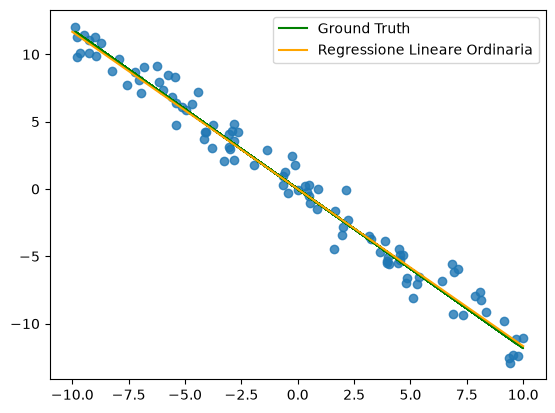

Pesi Ground Truth:  [-1.18269089]
Pesi Regressione Lineare Ordinaria:  [-1.16734993]


In [6]:
# Creiamo un intervallo di valori equispaziati per x
xlin = np.linspace(-10,10,100)

# Calcoliamo i valori y previsti per il modello non regolarizzato
ypred = wclose*xlin

plt.plot(X_reg, y_reg, 'o', alpha = 0.8)
plt.plot(X_reg, np.dot(X_reg,w), label='Ground Truth', color='green')
plt.plot(xlin, ypred, label='Regressione Lineare Ordinaria', color='orange')
plt.legend()
plt.show()

print("Pesi Ground Truth: ", w)
print("Pesi Regressione Lineare Ordinaria: ", wclose)

## Alcune note su Bias e Varianza

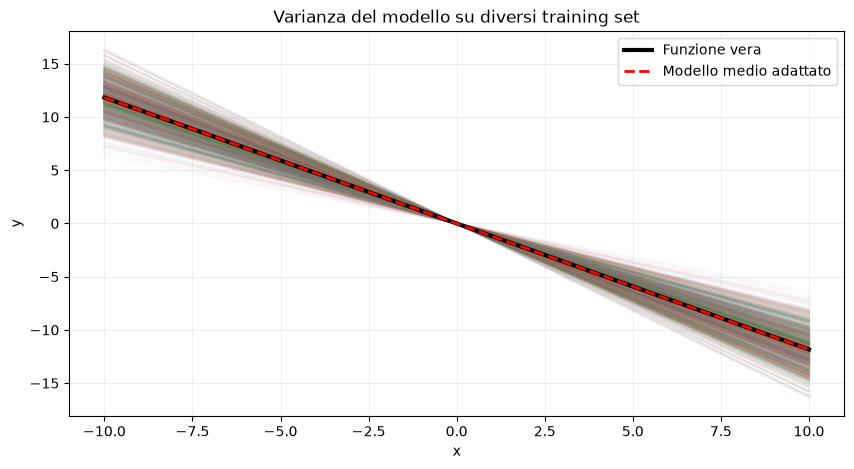

In [7]:
# Varianza del modello: addestriamo lo stesso modello su molti training set diversi
ws = []
plt.figure(figsize=(10, 5))

for i in range(1000):
    X_reg, y_reg = datagen(d, points, m, M, w, 10)
    wclose = CloseRegression(X_reg, y_reg)
    ws.append(wclose[0])

    plt.plot(xlin, wclose[0] * xlin, alpha=0.05)

# Funzione vera
plt.plot(xlin, w[0] * xlin, 'k', linewidth=3, label='Funzione vera')

# Modello medio adattato
w_mean = np.mean(ws)
plt.plot(xlin, w_mean * xlin, 'r--', linewidth=2, label='Modello medio adattato')

plt.title('Varianza del modello su diversi training set')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

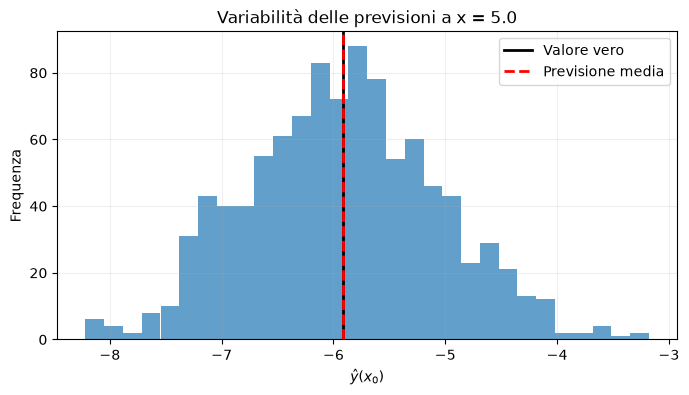

In [9]:
# Variabilità della previsione per un x fissato
x0 = 5.0

ypreds = np.array(ws) * x0

plt.figure(figsize=(8, 4))
plt.hist(ypreds, bins=30, alpha=0.7)

# Valore vero
y_true = w[0] * x0
plt.axvline(y_true, color='black', linewidth=2, label='Valore vero')

# Previsione media
plt.axvline(np.mean(ypreds), color='red', linestyle='--',
            linewidth=2, label='Previsione media')

plt.xlabel(r'$\hat{y}(x_0)$')
plt.ylabel('Frequenza')
plt.title(f'Variabilità delle previsioni a x = {x0}')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
/tmp/ipykernel_5463/4166193736.py:33: RankWarning: Polyfit may be poorly conditioned
  model_high = np.pol

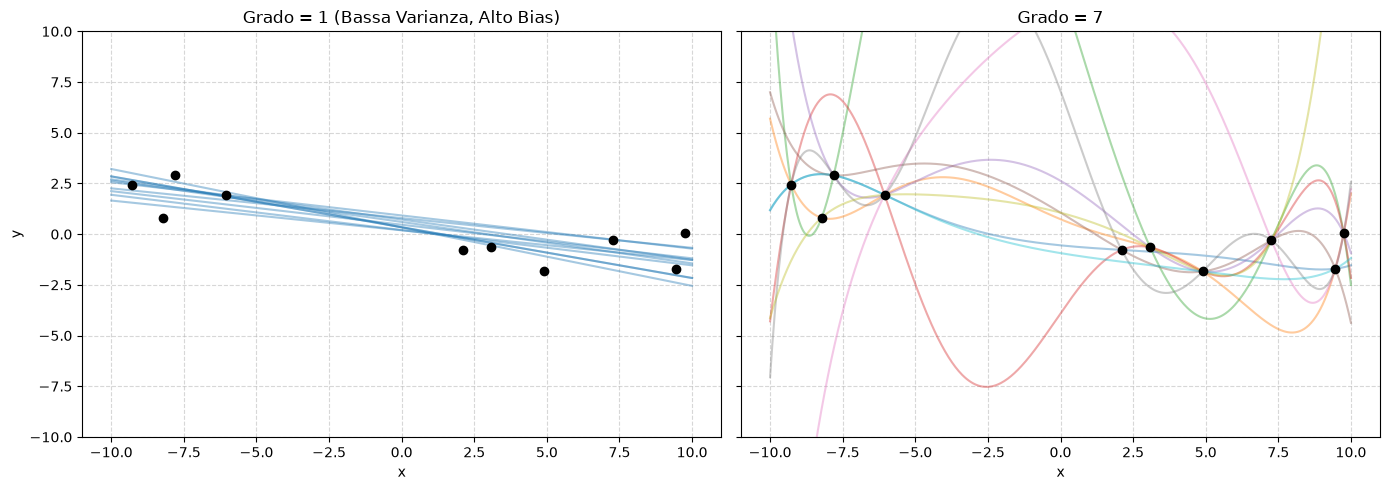

In [10]:
n_points = 10
n_models = 10 
bootstrap_size = 8

# Grado del modello più complesso
deg_high = 7

# Generiamo i dati
d = 1
w = np.random.normal(0, 1, d)
sigma = 1
points = 100
m = -10
M = 10
x_train, y_train = datagen(d, n_points, m, M, w, sigma)

x_eval = np.linspace(m, M, 512)

ys_linear = []
ys_high_deg = []

for _ in range(n_models):
    # Bootstrap
    boot_idx = np.random.choice(n_points, size=bootstrap_size, replace=True)
    x_curr = x_train[boot_idx]
    y_curr = y_train[boot_idx]

    # Adattiamo un polinomio di grado 1
    model_lin = np.polyfit(x_curr.squeeze(-1), y_curr, 1)
    ys_linear.append(np.polyval(model_lin, x_eval))

    # Adattiamo un polinomio di grado superiore
    model_high = np.polyfit(x_curr.squeeze(-1), y_curr, deg_high)
    ys_high_deg.append(np.polyval(model_high, x_eval))


# Grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.scatter(x_train, y_train, color="black", zorder=5)
for y in ys_linear:
    ax1.plot(x_eval, y, color="tab:blue", alpha=0.4)
ax1.set_title("Grado = 1 (Bassa Varianza, Alto Bias)")

ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_ylim(m, M)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.scatter(x_train, y_train, color="black", zorder=5)
for y in ys_high_deg:
    ax2.plot(x_eval, y, alpha=0.4)
ax2.set_title(f"Grado = {deg_high}")
ax2.set_xlabel("x")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

---

## Metodo della Discesa del Gradiente (GD)

**Ricorda**: il gradiente indica la direzione di massima salita di una funzione. Quindi, per trovare il minimo di una funzione, dobbiamo seguire la direzione del gradiente negativo. Nella GD facciamo un passo di ampiezza $\gamma$ (learning rate). Data una funzione di loss $\mathcal{L}(w)$, funziona così:

1. Inizializziamo $w_0$
2. while (condizione):
   * calcoliamo il gradiente della loss al tempo $t$: $\nabla_w \mathcal{L}|_t$
   * aggiorniamo i pesi come $w_{t+1} = w_t - \gamma \nabla_w \mathcal{L}|_t $

Nel caso della regressione lineare, la loss dell'errore quadratico e il suo gradiente sono:

$$
\mathcal{L}=\frac{1}{n}\|y-Xw\|_{2}^{2},\;\;\;\;\nabla_{w} \mathcal{L} = -\frac{2}{n}X^T(y-Xw)
$$

Come condizione per il ciclo while usiamo un numero predefinito di iterazioni.

In sintesi, la Discesa del Gradiente è una tecnica di ottimizzazione iterativa che regola un vettore di parametri per minimizzare una funzione di loss. Lo fa compiendo passi nella direzione del gradiente negativo, convergendo gradualmente verso il minimo della funzione. Per la regressione lineare, questo significa trovare la retta che meglio si adatta ai dati, minimizzando l'errore quadratico tra previsioni e valori reali.


In [11]:
def SquareLoss(X, y, w):
    """
    Parametri
    ----------
    - X : array di float di dimensione n x d
        Matrice contenente il dataset

    - y : array di float di dimensione n
        Vettore contenente il valore ground truth di ciascun punto dati

    -w : array di float di dimensione d
        Pesi della retta adattata
    """
    return np.linalg.norm(y - X@w, 2)

La funzione calcola la loss quadratica nel modo seguente:

1. `X @ w`: è la moltiplicazione matrice-vettore del dataset `X` con il vettore dei pesi `w`. Il risultato è un vettore di valori previsti, uno per ciascun punto dati.

2. `y - X @ w`: calcola la differenza elemento per elemento tra i valori veri `y` e i valori previsti ottenuti al passo precedente.

3. `LA.norm(y - X @ w, 2)`: calcola la norma L2 (norma euclidea) del vettore ottenuto al passo 2, che è essenzialmente la radice quadrata della somma dei quadrati delle differenze tra valori veri e previsti.

4. La norma L2 calcolata rappresenta la loss quadratica, che misura quanto bene le previsioni del modello lineare corrispondono ai valori reali. Valori più piccoli indicano un adattamento migliore del modello, mentre valori più grandi indicano errori di previsione maggiori.

In [12]:
def GD(X, y, iters, gamma, points, d, tol = 1e-3):
    """
    Parametri
    ----------
    - X : array di float di dimensione n x d
        Matrice contenente il dataset

    - y : array di float di dimensione n
        Vettore contenente il valore ground truth di ciascun punto dati

    - iters : int
        Numero di iterazioni della GD

    - gamma : float
        Learning rate

    -points : int
        Numero di punti nel nostro dataset

    - d : int
        Dimensionalità di ciascun punto dati nel dataset
    """
    # Inizializziamo gli array per memorizzare pesi e loss
    W = np.zeros((iters,d)) # Per memorizzare i pesi a ogni iterazione
    L = np.zeros(iters) # Per memorizzare le loss a ogni iterazione

    # Inizializziamo il vettore dei pesi w con piccoli valori casuali
    w = np.random.normal(0, 0.1, d)
    n = X.shape[0]

    # Iterazioni della GD
    W[0] = w
    L[0] = SquareLoss(X, y, w)/n
    for i in range(iters):
        gradiente = -(2/n) * X.T @ (y - X @ w)
        w = w - gamma * gradiente
        W[i] = w
        
        # Implementiamo il calcolo della loss e il controllo di convergenza
        loss = SquareLoss(X, y, w)/n
        L[i] = loss

        if loss < tol:
            W = W[:i+1]
            L = L[:i+1]
            break
    return i, W, L

In [13]:
# Determiniamo la dimensionalità del dataset
d = np.shape(X_reg)[1]

iters = 1000
n_points = 100
gamma = 0.001

# Applichiamo la Discesa del Gradiente (GD) per addestrare un modello di regressione lineare
i, wgd, L = GD(X_reg, y_reg, iters, gamma, points, d)
# gli ultimi pesi memorizzati sono quelli più aggiornati
wpred = wgd[i,:].T

In [14]:
w, wpred, np.abs(w-wpred)

(array([-0.12523222]), array([-1.14475862]), array([1.0195264]))

Text(0.5, 1.0, 'Squared Loss')

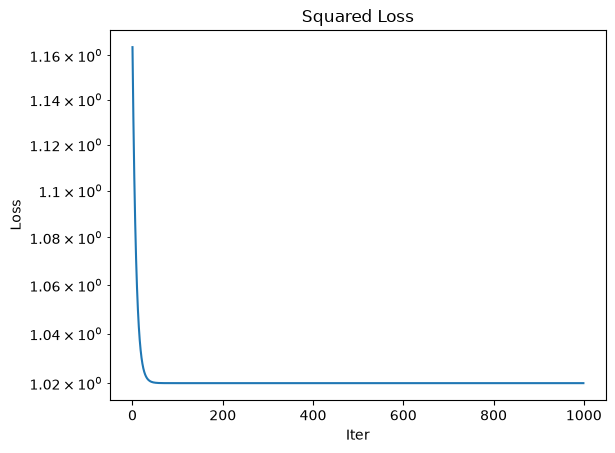

In [15]:
plt.plot(L)
plt.xlabel('Iter')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Squared Loss')

## Regressione Logistica

### Generiamo i dati e rappresentiamoli (con rumore) (vedi Lab 1)

In [16]:
def mixGauss(means, sigmas, n):
    """
    Parametri
    ----------
    - means : matrice/lista di float di dimensione n_classes x dim_data (d)
        Medie delle funzioni Gaussiane

    - sigmas : array/lista di float di dimensione n_classes
        Deviazione standard delle funzioni Gaussiane

    - n : int
        Numero di punti per ciascuna classe
    """
    means = np.array(means)
    sigmas = np.array(sigmas)

    d = np.shape(means)[1] # la matrice means è di n_classes x dim_data
    num_classes = sigmas.size # il numero di varianze è il numero di classi

    data = np.full((n * num_classes, d), np.inf)
    labels = np.zeros(n * num_classes)

    # iteriamo sulle classi
    for idx, sigma in enumerate(sigmas):
        # genera n punti attorno a means[idx] con cov sigma[idx]
        data[idx * n:(idx + 1) * n] = np.random.multivariate_normal(
            mean=means[idx], cov=np.eye(d) * sigmas[idx] ** 2, size=n)
        labels[idx * n:(idx + 1) * n] = idx

    if(num_classes == 2):
        labels[labels == 0] = -1

    return data, labels

def labelsnoise(perc, labels):
    """
    Parametri
    ----------
    - perc : float
        Percentuale di etichette da invertire

    - labels: array di int di dimensione n_classes
        Array contenente gli indici delle etichette
    """
    points = np.shape(labels)[0]
    noisylabels = np.copy(np.squeeze(labels))
    n_flips = int(np.floor(points * perc / 100)) # floor: intero più vicino per difetto
    idx_to_flip = np.random.choice(points, size=n_flips, replace=False) # replace è false poiché lo stesso indice non può essere scelto due volte
    noisylabels[idx_to_flip] = -noisylabels[idx_to_flip] # per il caso binario questo trasforma -1 in 1 e viceversa
    return noisylabels

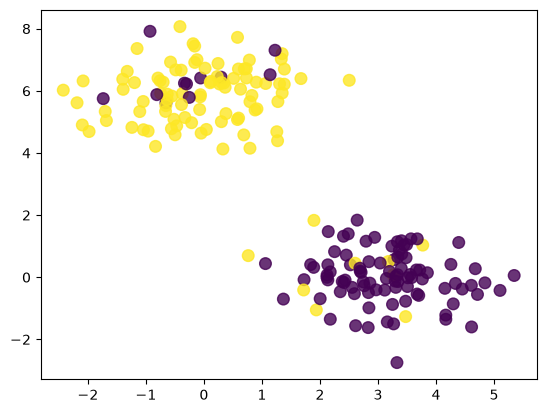

In [17]:
# esempio d'uso
means = [[3,0],[0,6]]
sigmas = [0.9,0.9]
n = 100

X, labels = mixGauss(means, sigmas, n)
labels = labelsnoise(10, labels) # il 10% delle etichette è invertito

# grafico del dataset generato
plt.scatter(X[:,0], X[:,1], s=70, c=labels, alpha=0.8)
plt.show()

***Funzione Sigmoide***

$$
\sigma(wx_i) = \frac{1}{1 + e^{-wx_i}}
$$


La funzione sigmoide, spesso indicata con σ o funzione sigmoid, è una funzione matematica comunemente utilizzata nel machine learning e nella statistica. Mappa qualsiasi numero reale 'wx_i' su un valore compreso tra 0 e 1.

- **'wx_i'**: è l'input alla funzione sigmoide. È un numero reale ottenuto dal prodotto scalare tra un peso 'w' e una feature 'x_i'. 'w' rappresenta un parametro di peso e 'x_i' rappresenta una variabile di input.

- **'$1 + e^{-wx_i}$'**: qui '1' viene sommato al risultato ottenuto al passo precedente. Questa somma garantisce che il denominatore non sia mai zero.

- **'$\frac{1}{1 + e^{-wx_i}}$'**: infine, la funzione prende il reciproco del risultato del passo precedente, il che garantisce che l'output della funzione sigmoide sia nell'intervallo (0, 1).

In sintesi, la funzione sigmoide prende un input 'wx_i', applica una trasformazione matematica che coinvolge esponenziazione e divisione, e produce un output compreso tra 0 e 1. È spesso usata nel machine learning per compiti come la classificazione binaria, dove mappa i valori di input su probabilità. Quando 'wx_i' è positivo, la funzione sigmoide si avvicina a 1, mentre quando 'wx_i' è negativo si avvicina a 0, rendendola utile per modellare probabilità o confini decisionali.

In [18]:
def sigmoid(x, w):
    """
    Parametri
    ----------
    - x : array di dimensione n
        Array contenente il datapoint
        
    - w : float
        Numero che rappresenta la 'temperatura' della sigmoide
    """
    y = 1 / (1 + np.exp(-w * x))
    return y

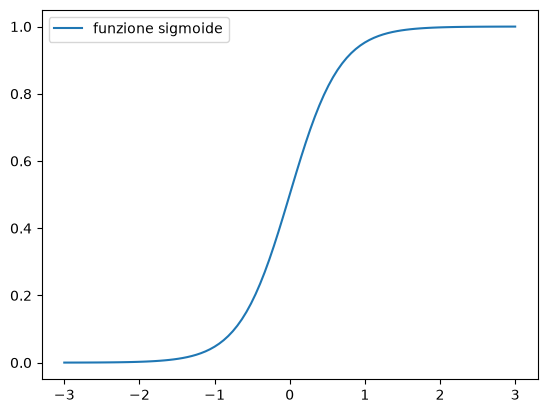

In [19]:
# esempio d'uso
x = np.linspace(-3,3,100)
w = 3
y = sigmoid(x, w)

plt.plot(x, y, label='funzione sigmoide')
plt.legend()
plt.show()

## Logistic Loss

Nella regressione logistica, l'obiettivo è modellare la probabilità che un dato input 'x' appartenga a una particolare classe (di solito 0 o 1). Per fare ciò, la regressione logistica impiega una funzione ipotesi 'h(x)' che trasforma la combinazione lineare di feature e pesi 'w^T*x' in un valore di probabilità usando la funzione sigmoide 'σ(wx)'.

* Per la regressione l'ipotesi era: $h(x)=w^Tx$
* Per la regressione logistica è $h(x)=\sigma(w,x)=\frac{1}{1+e^{-w^Tx}}$

- **Confine Decisionale**: la regressione logistica prende decisioni di classificazione binaria basandosi sul valore di 'h(x)':

$$
h(x) =
\begin{cases}
  >0.5, & w^{T}x>0\\
  <0.5, & w^{T}x<0
\end{cases}
$$

  Se 'h(x)' è maggiore di 0.5, il modello predice la classe 1; altrimenti predice la classe 0. La soglia di 0.5 è quella comunemente usata, ma può essere modificata a seconda del problema.

**Formula della Logistic Loss**


La logistic loss è una misura usata per valutare la bontà dell'adattamento di un modello di regressione logistica. Quantifica la differenza tra le previsioni del modello (date da 'h(x,w)') e le etichette binarie reali 'y'. Ecco la formula della logistic loss:

$$
L=-y\cdot \log(h(x,w))-(1 - y)\cdot \log(1-h(x,w))
$$

  - 'y' rappresenta l'etichetta binaria reale (0 o 1).
  - 'h(x,w)' è la probabilità prevista che 'x' appartenga alla classe 1 secondo il modello di regressione logistica con pesi 'w'.

La logistic loss misura quanto bene le probabilità previste dal modello si allineano con le etichette binarie reali. Quando l'etichetta reale 'y' è 1, il primo termine misura la loss associata al fatto che il modello predica la classe 0 quando dovrebbe essere 1. Analogamente, quando 'y' è 0, il secondo termine misura la loss associata al fatto che il modello predica la classe 1 quando dovrebbe essere 0.

**Minimizzazione della Logistic Loss**

Per addestrare un modello di regressione logistica, è necessario trovare l'insieme ottimale di pesi 'w' che minimizza la logistic loss. Questo viene tipicamente fatto usando un algoritmo di ottimizzazione come la discesa del gradiente. Ecco la regola di aggiornamento per minimizzare la logistic loss con la discesa del gradiente:

$$
w_{j}\leftarrow w_{j}-\frac{\gamma}{n}\sum_{i=1}^{n}(h(x^{i})-y^{i})x^{i}_{j}
$$
In forma compatta:

$$
w\leftarrow w -\frac{\gamma}{n}X^{T}(h(X)-y)
$$

La regola di aggiornamento regola essenzialmente ciascun peso 'w_j' in base alla differenza tra la previsione del modello e l'etichetta reale per ciascun punto dati. L'obiettivo è aggiornare iterativamente i pesi per minimizzare la logistic loss, portando infine a un modello di regressione logistica ben adattato per la classificazione binaria.



In [20]:
# questa è una versione vettorizzata per ottenere l'output logistico per l'intera matrice in una volta
def sigmoidM(X, w):
    """
    Parametri
    ----------
    X : array di dimensione n x d
        Matrice contenente il dataset
    w : array di dimensione d
        Vettore che rappresenta i coefficienti del modello logistico
    """
    y = 1/(1 + np.exp(-np.matmul(X,w)))
    return y

- `np.matmul(X, w)` calcola il prodotto scalare tra la matrice delle feature `X` e il vettore dei coefficienti `w` per ciascun punto dati. Questo calcola essenzialmente la parte lineare del modello di regressione logistica.

- `np.exp(-np.matmul(X, w))` calcola l'esponenziale della combinazione lineare negativa.

- `1 / (1 + np.exp(-np.matmul(X, w)))` applica la trasformazione sigmoide a ciascun elemento della combinazione lineare, ottenendo un vettore di probabilità. Queste probabilità rappresentano la verosimiglianza che ciascun punto dati appartenga alla classe positiva nella classificazione binaria.

In [21]:
def LogisticLoss(X, y, w):
    """
    Parametri
    ----------
    - X : array di dimensione n x d
        Matrice contenente il dataset

    - y : array di dimensione n
        Vettore che rappresenta l'etichetta ground truth di ciascun punto dati
        
    - w : array di dimensione d
        Vettore che rappresenta i coefficienti del modello logistico
    """
    cost = -y * (np.log(sigmoidM(X,w))) - (1 - y) * np.log(1 - sigmoidM(X,w))
    return cost

  - `labels * log(sigmoid(Xw))` calcola la log-verosimiglianza della classe reale (1) per ciascun punto dati quando il modello predice la probabilità usando `sigmoidM(X, w)`. Questa parte misura quanto bene il modello predice gli esempi positivi quando l'etichetta reale è 1.

  - `(1 - labels) * log(1 - sigmoid(Xw))` calcola la log-verosimiglianza della classe reale (0) per ciascun punto dati quando il modello predice la probabilità. Questa parte misura quanto bene il modello predice gli esempi negativi quando l'etichetta reale è 0.

  - La somma su tutti i punti dati e il fattore di scala negativo `(1/n)` calcolano la media della logistic loss sull'intero dataset.

Questo codice calcola la logistic loss, che quantifica quanto bene le previsioni di un modello di regressione logistica corrispondono alle etichette reali in un problema di classificazione binaria.

In [22]:
def GDLogistic(X, labels, iters, gamma):
    """
    Parametri
    ----------
    - X : array di dimensione n x d
        Matrice contenente il dataset

    - labels : array di dimensione n
        Vettore che rappresenta l'etichetta ground truth di ciascun punto dati

    - iters : int
        Numero di iterazioni della GD
        
    - gamma : float
        Learning rate
    """
    d = np.shape(X)  # d contiene la forma di X, che è una tupla (n, d)
    loss = np.zeros(iters)  # Creiamo un array per memorizzare la loss a ciascuna iterazione
    w = np.random.uniform(0, 0.01, d[1])  # Inizializziamo w con valori casuali
    W = np.zeros((iters, 2))  # Creiamo un array per memorizzare i vettori dei pesi a ciascuna iterazione
    n = X.shape[0]

    for i in range(iters):
        # Salvo i pesi correnti nella matrice W
        W[i] = w

        # Calcolo il vettore degli errori per ogni singolo dato
        loss_vector = LogisticLoss(X, labels, w)

        # Calcolo la loss media su tutto il dataset
        loss[i] = np.sum(loss_vector) / n

        # Calcolo le probabilità correnti
        preds = sigmoidM(X, w)

        # Calcolo il gradiente e aggiorno i pesi
        gradiente = (1/n) * X.T @ (preds - labels)
        w = w - gamma * gradiente

    return W, loss

In [23]:
# esempio d'uso
iters = 1000
gamma = 0.0001
W, cost = GDLogistic(X, labels, iters, gamma)

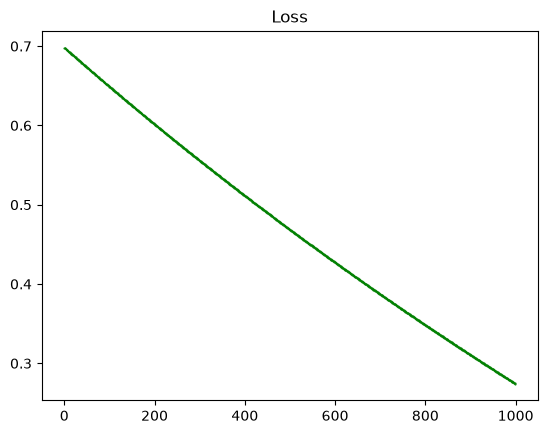

In [24]:
plt.plot(cost, 'go', markersize=0.5)
plt.title('Loss')
plt.show()

***Rappresentazione del confine decisionale***

Il confine decisionale è usato per predire a quale classe potrebbe corrispondere un nuovo punto.
Il confine decisionale in un problema di classificazione è una costruzione matematica che separa classi o categorie diverse nello spazio delle feature.

La sua derivazione è:

$$0=w^{T}x=x_{1}w_{1}+x_{2}w_{2}\rightarrow x_{2}=-\frac{x_{1}w_{1}}{w_{2}}$$

In termini pratici, quando hai addestrato un modello di regressione logistica o di classificazione lineare, il confine decisionale è la retta (in 2D) o l'iperpiano (in dimensioni superiori) che separa le due classi. I nuovi punti dati vengono classificati in base a quale lato del confine decisionale cadono. Se cadono da un lato, vengono assegnati alla classe 0, mentre se cadono dall'altro lato, vengono assegnati alla classe 1. L'equazione fornita aiuta a calcolare la posizione di questo confine in termini di valori delle feature e dei pesi del modello.


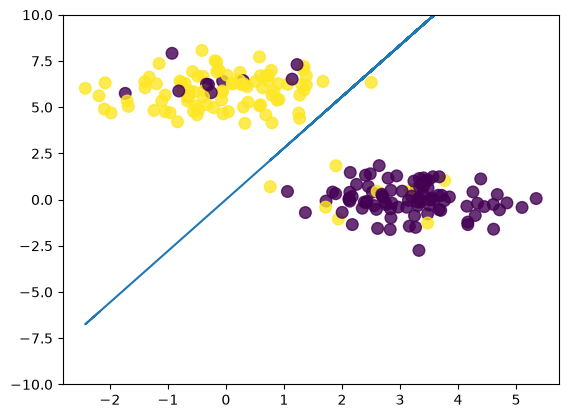

In [25]:
w = W[iters-1, :]
y = -(np.dot(X[:,0], w[0])/w[1])

plt.scatter(X[:,0], X[:,1], s=70, c=labels, alpha=0.8)
plt.plot(X[:,0], y)
plt.ylim([m, M])
plt.show()

## Accuracy

L'accuracy è una metrica usata per i problemi di classificazione, definita come il numero di previsioni corrette diviso il numero totale di previsioni.

In [26]:
def accuracy(X, w, labels):
    """
    Parametri
    ----------
    - X : array di dimensione n x d
        Matrice contenente il dataset

    - w : array di dimensione d
        Vettore che rappresenta i coefficienti del modello logistico

    -labels : array di dimensione n
        Vettore che rappresenta l'etichetta ground truth di ciascun punto dati
    """
    a = labels - (2*np.round(sigmoidM(X,w))-1)
    acc = np.sum(a==0)/np.shape(X)[0]
    return acc

 Per la variabile `a`
  - `np.round(sigmoidM(X,w))`: calcola l'output della funzione sigmoide per ciascun punto dati nel dataset.
  - `2*np.round(sigmoidM(X,w))-1`: questa riga scala gli output della sigmoide in modo che siano 1 o -1.
  - `labels - (2*np.round(sigmoidM(X,w))-1)`: sottrae le etichette ground truth dagli output della sigmoide scalati. Il risultato è un array in cui un valore pari a 0 indica una previsione corretta, mentre valori non nulli indicano previsioni errate.

Per la variabile `acc`

- Questa riga calcola l'accuracy contando il numero di previsioni corrette (dove `a` è uguale a 0) e dividendolo per il numero totale di punti dati (`np.shape(X)[0]`), il che dà la proporzione di punti dati classificati correttamente.

In [ ]:
accuracy(X, w, labels)

---

4. Esploriamo le funzioni di `scikit-learn` per la regressione lineare e logistica.

In [ ]:
#%pip install scikit-learn

* Linear Regression: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [ ]:
from sklearn.linear_model import LinearRegression

# Inizializzo il modello di regressione lineare
lin_reg = LinearRegression()

# Alleno il modello passando la matrice delle feature e il vettore target
lin_reg.fit(X_reg, y_reg)

# Stampo i pesi calcolati dal modello
print("Pesi calcolati (Linear Regression):", lin_reg.coef_)

* Logistic Regression: [LogisticRregression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inizializzo il modello per la classificazione
log_reg = LogisticRegression()

# Alleno il classificatore sulle feature e le etichette reali
log_reg.fit(X, labels)

# Stampo i coefficienti del decision boundary
print("Pesi calcolati (Logistic Regression):", log_reg.coef_)

---

## Domande tipo esame

- Cosa significa "lineare" nella regressione lineare?
- Cosa rappresenta la varianza nel contesto di un modello di regressione?
- Fai un esempio di modello non lineare (diverso da quello logistico)
- Cosa rappresenta il confine decisionale nella regressione logistica?
- Qual è il legame tra la cross-entropy e la stima di massima verosimiglianza (MLE)?